# Tracking aspherical particles from 2D brightfield images

In [182]:
already_saved = False

# Importations

In [134]:
import numpy as np
import pandas as pd

import pims
import trackpy as tp

import cv2

from skimage.measure import label, regionprops, find_contours

from tqdm import tqdm
import os
import time 

from scipy.optimize import curve_fit

In [122]:
# import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import rc

# change the following to %matplotlib notebook for interactive plotting
%matplotlib inline

# Optionally, tweak styles.
rc('lines', linewidth=1.5, markeredgecolor='k', markeredgewidth=0.5)
rc('xtick', direction='in', labelsize=10)
rc('ytick', direction='in', labelsize=10)
rc('font', family='serif', size=10)
rc('text', usetex=True)
rc('image', cmap='gray')
rc('figure', dpi=200)
rc('savefig', dpi=200)

In [3]:
# import sys
# sys.path.append("/home/nfares/postdoc/experiments/tracking/wraptrack_scikit/")

# import wraptrack_scikit as wt

In [ ]:
# os.environ["OMP_NUM_THREADS"] = "30"
# os.environ["MKL_NUM_THREADS"] = "30"

# Auxiliary functions

In [5]:
# def normalize8(I):
#     mn = I.min()
#     mx = I.max()
#     I = ((I - mn) / (mx - mn)) * 255
#     return I.astype(np.uint8)

# Inputs

In [178]:
# Where to find the data
# path2vid = '/mnt/share/nfares/group/palacgrp/Nicolas/20260528_rotation_in_THF/3p6_3p0.mp4'
path2vid = '/home/nfares/postdoc/experiments/sam/shell_stuck_on_surface/TriAmineChip3/position2_NaOH_2_going_back_from_salt/1Hz_3.5_3.2_c.mp4'

# Frame rate
fps = 1000

# Pixel size (in m)
px = 130e-9

# Get the frames 

In [7]:
@pims.pipeline
def gray(image, channel=2):
    return image[:, :, channel]  # Take just one channel
    # return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

frames = gray(pims.open(path2vid))
# frames = pims.open(path2vid)

# PyAV-based reading

In [8]:
frames

(PyAVReaderTimed,) processed through proc_func. Original repr:
    <Frames>
    Format: QuickTime / MOV
    Source: /home/nfares/postdoc/experiments/sam/shell_stuck_on_surface/TriAmineChip3/position2_NaOH_2_going_back_from_salt/1Hz_3.5_3.2_c.mp4
    Duration: 45.393 seconds
    Frame rate: 1000.022 fps
    Length: 45394 frames
    Frame Shape: (192, 288, 3)
    

In [9]:
len(frames)

45394

# Compute the background

In [11]:
# Uncomment next line if you want to compute the background as the ''moving background''

In [12]:
# indexes = np.arange(0, 800, 10)
# bg = np.median(frames[indexes], axis=0)
# plt.figure()
# plt.imshow(bg)
# plt.show()

In [13]:
# Uncomment next cell if you want to load the background

In [14]:
# bg = cv2.imread('background.tiff')
# bg = gray(bg)
# plt.figure()
# plt.imshow(bg)
# plt.show()

In [15]:
# Uncomment next cell if you want to use a ''black'' background

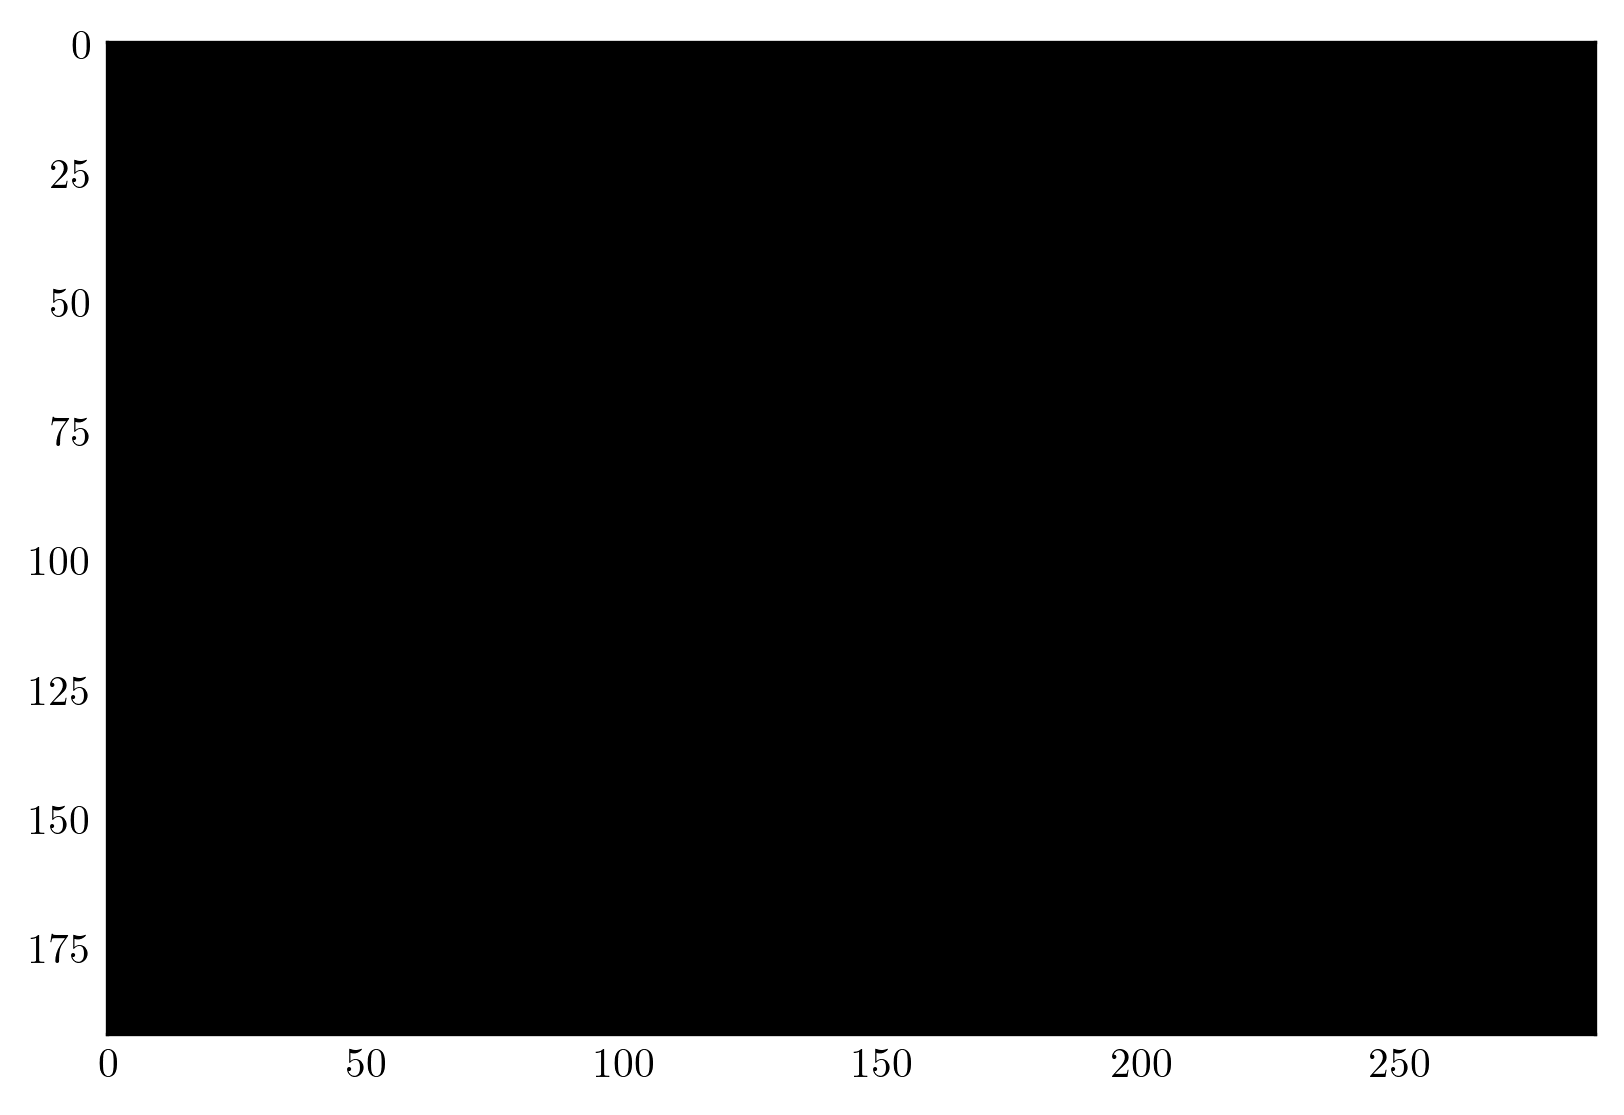

In [16]:
bg = np.zeros_like(frames[0])

plt.figure()
plt.imshow(bg)
plt.show()

# One image: Track Particles

In [17]:
# Choose an image

index = 420

In [18]:
im1 = frames[index]

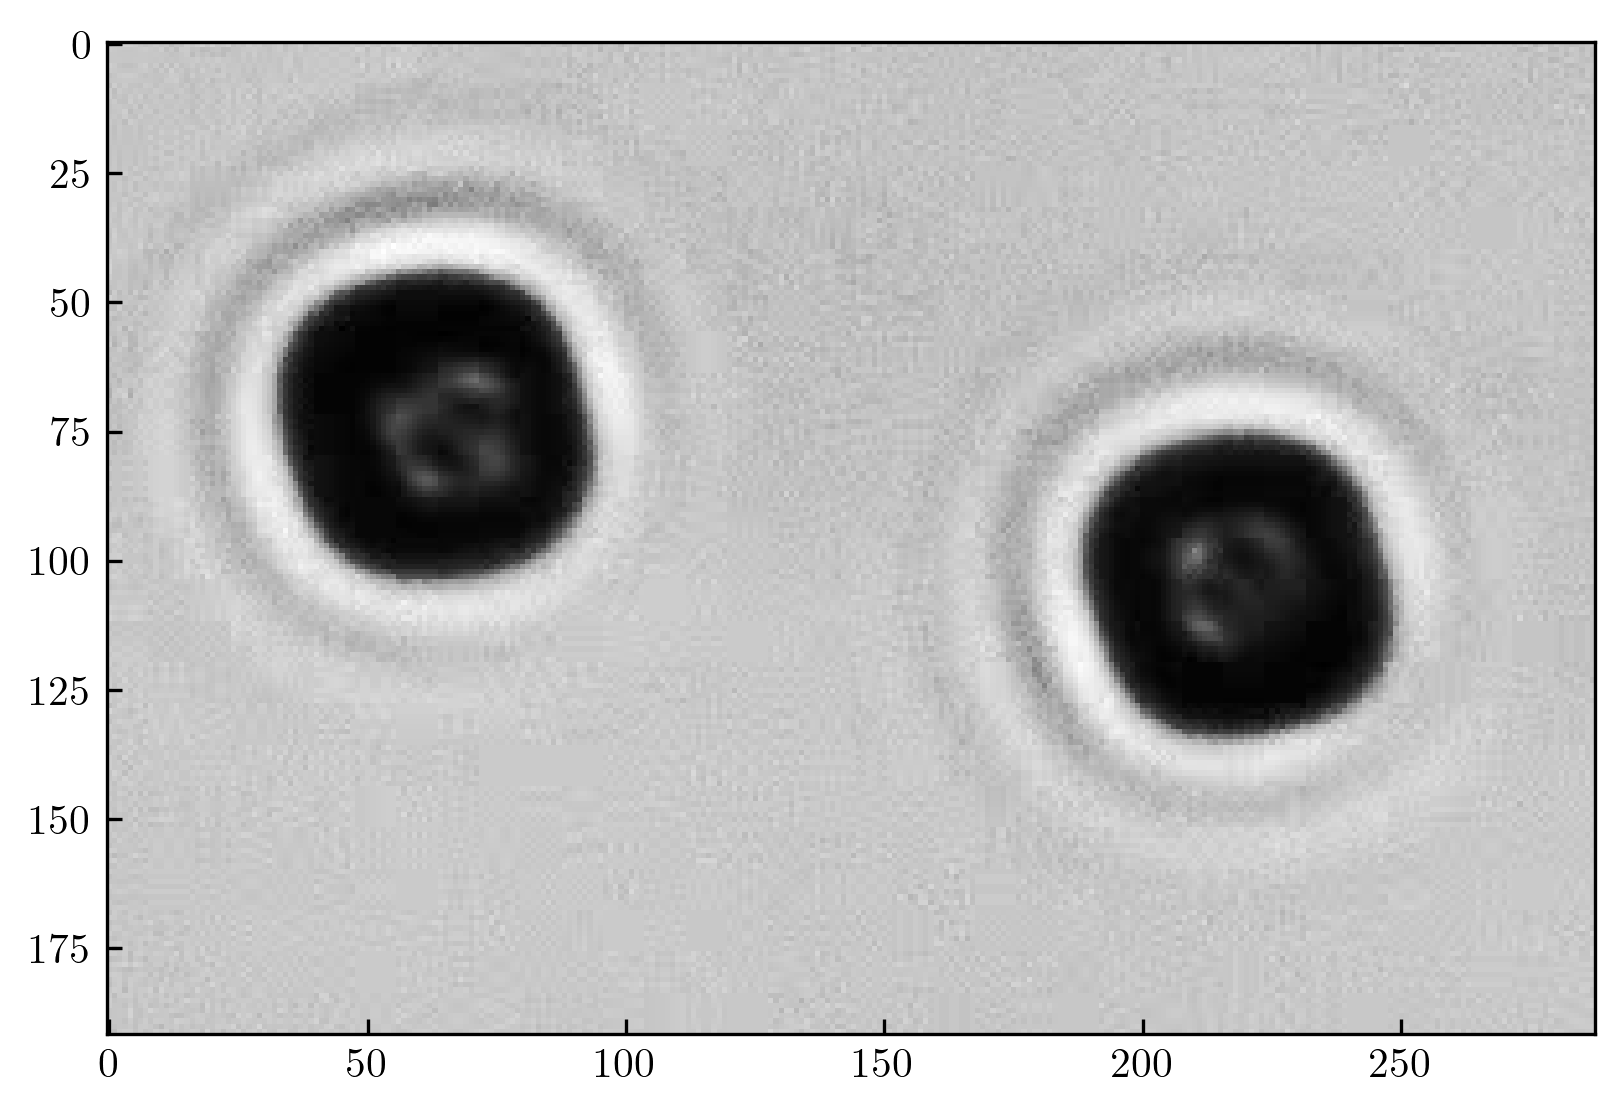

In [19]:
plt.imshow(im1);

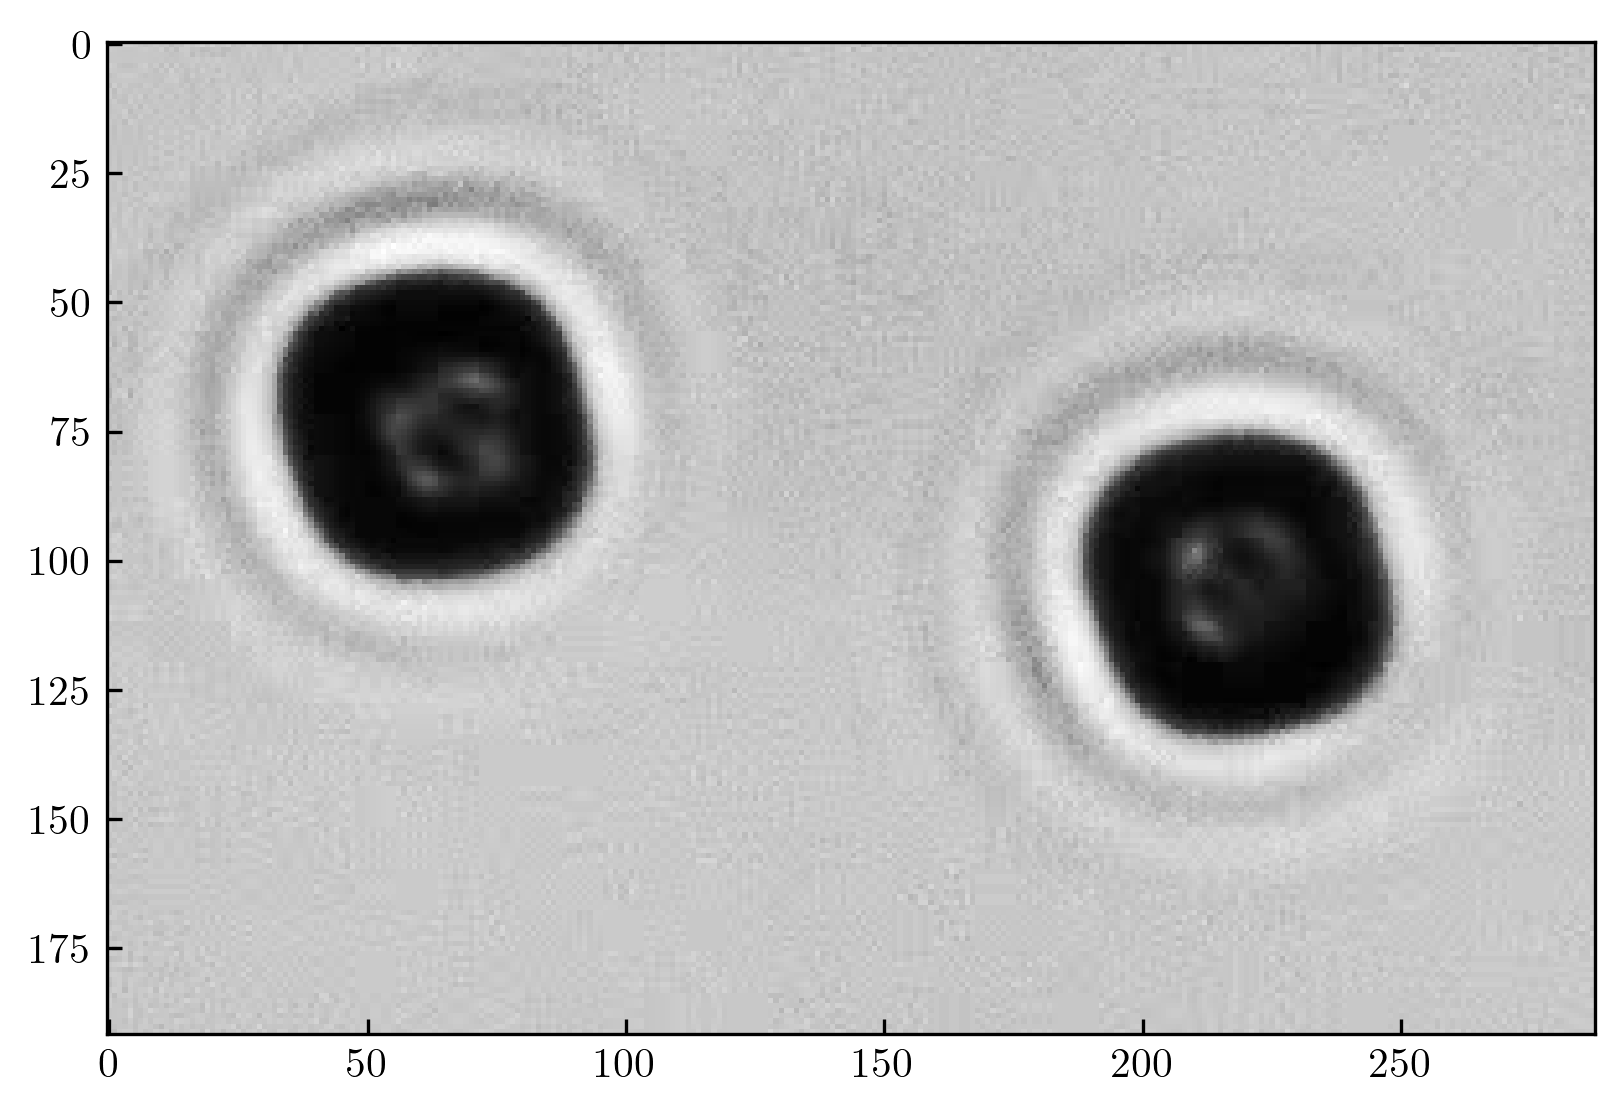

In [20]:
# Remove backgrouond and show

def remove_background(img, bg):
    return img - bg

im2 = remove_background(im1, bg)
# im2 = im1
plt.imshow(im2)

In [21]:
# Track with trackpy

f2 = tp.locate(im2, 105, invert=True, minmass=3000, separation=105)
f2.head()

,y,x,mass,size,ecc,signal,raw_mass,ep,frame
0,73.656348,62.831929,353336.197439,23.462977,0.056813,142.468988,1020192.0,0.014158,420
1,105.031985,218.662185,339837.545762,23.044954,0.069622,145.318368,1005910.0,0.014613,420


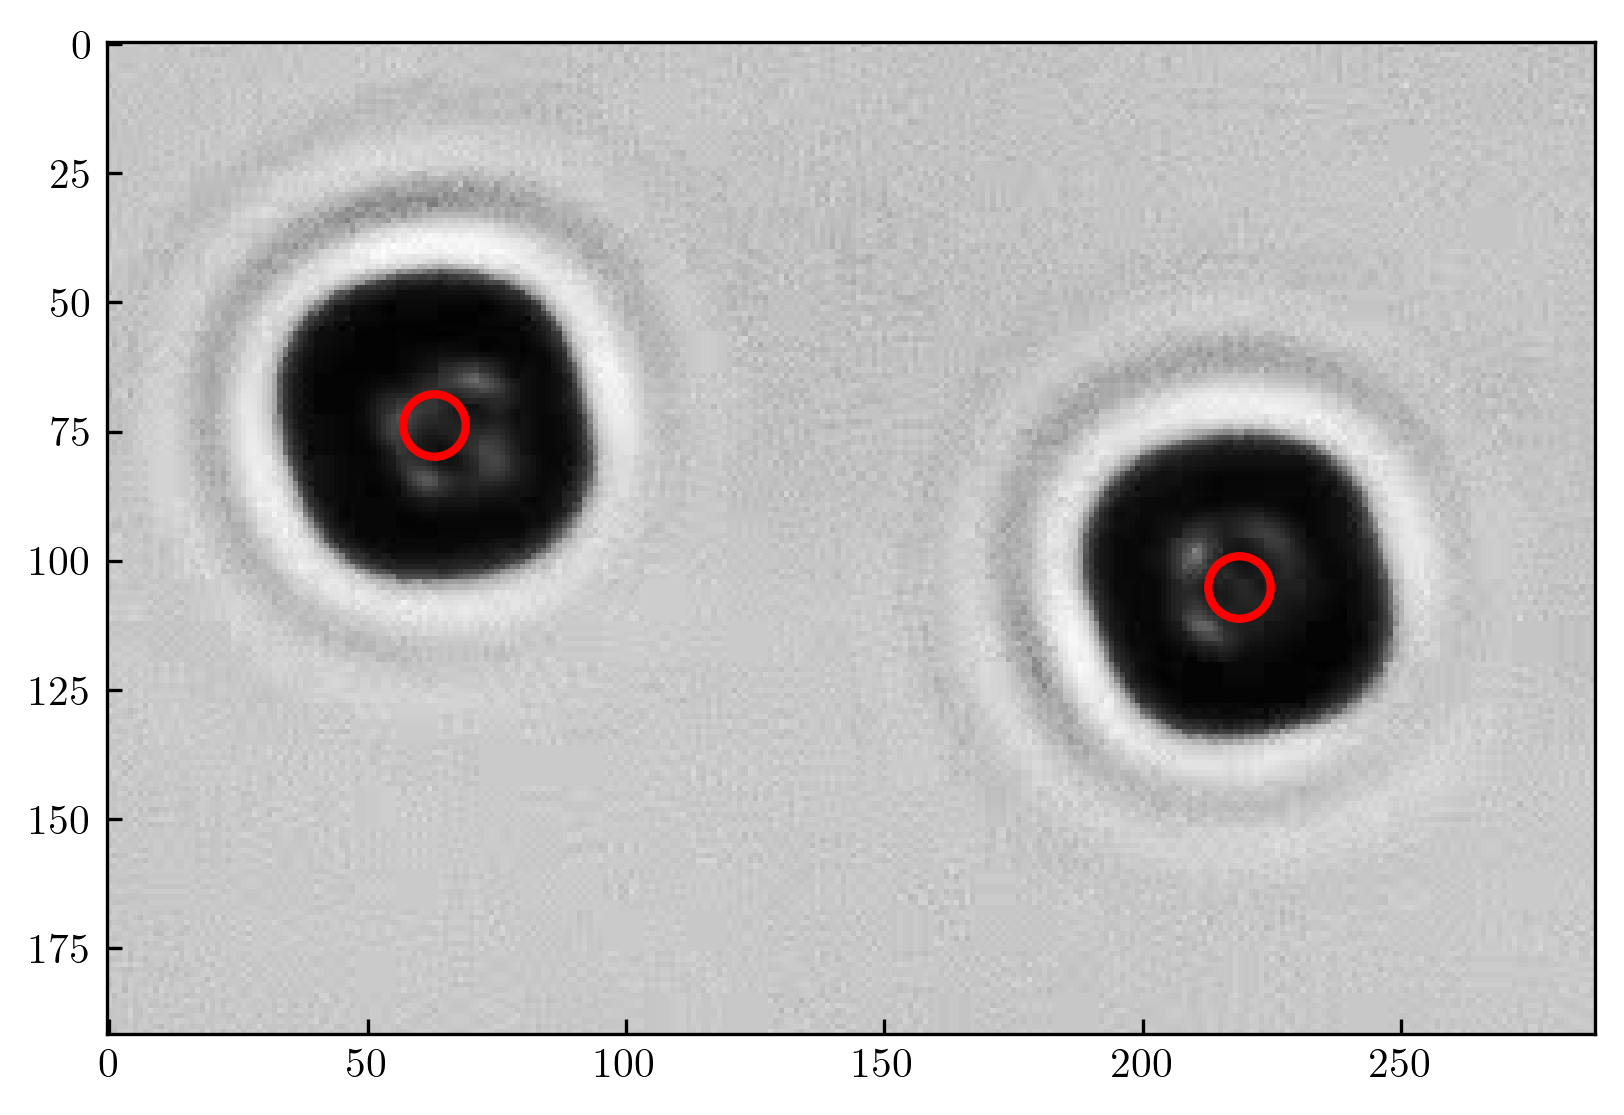

In [22]:
tp.annotate(f2, im2);

In [23]:
# Check sub-pixel accuracy

# tp.subpx_bias(f2);

# Here I changed DataFrame.applymap to DataFrame.map in the source code, because of an update in pandas.
# Source code:
# ~/miniforge3/envs/ista/lib/python3.12/site-packages/trackpy/plots.py

In [24]:
# frame = im2

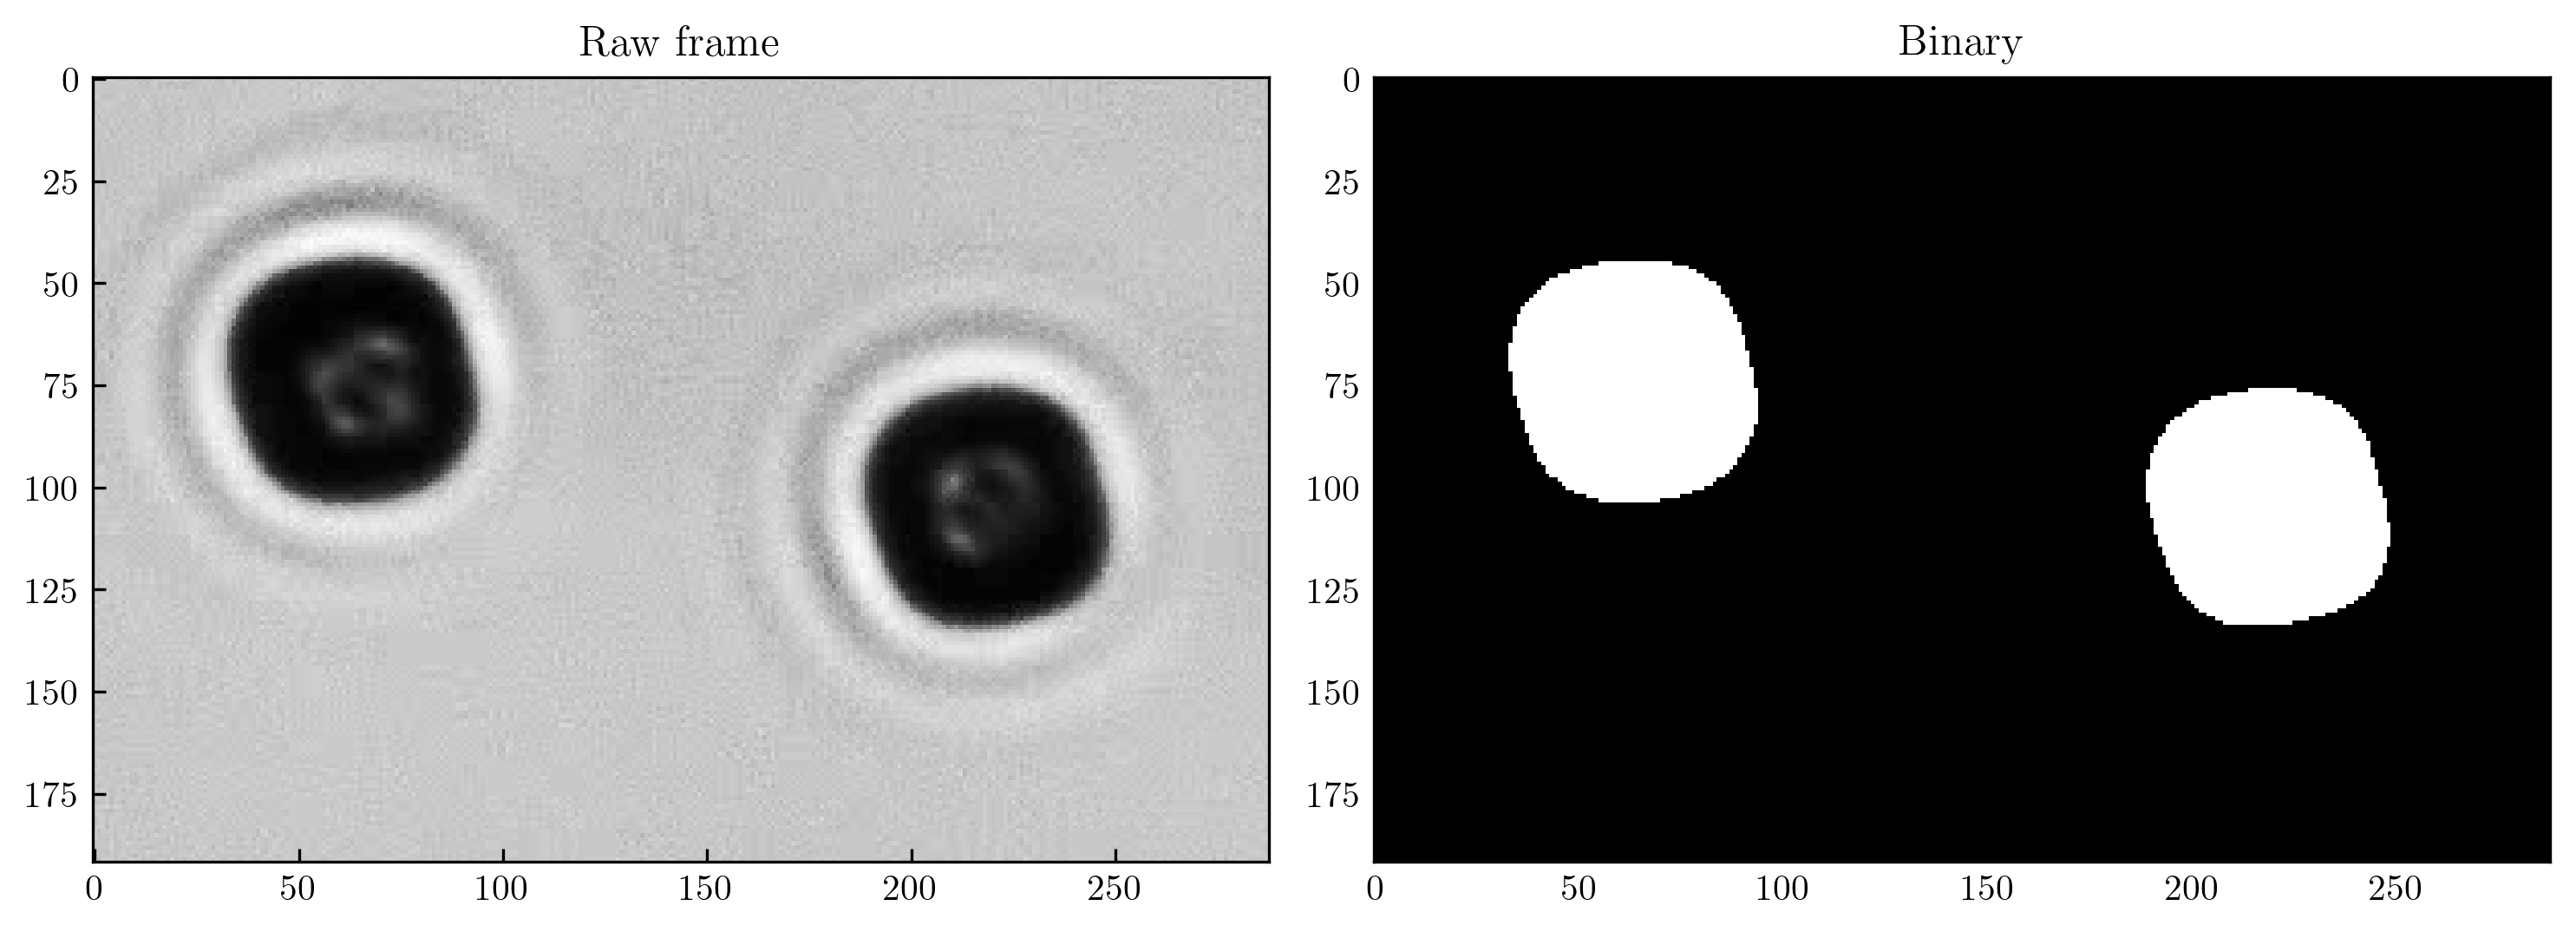

In [25]:
# Binarize the image

# --- tune these ---
BLUR_SIGMA     = 1.5
THRESH_METHOD  = 'otsu'   # 'otsu' | 'manual'
THRESH_VALUE   = 128      # used only when THRESH_ME

def make_binary(frame, blur_sigma=1.5, thresh_method='otsu', thresh_value=128, invert=True):
    ksize = int(6 * blur_sigma) | 1
    blurred = cv2.GaussianBlur(frame, (ksize, ksize), blur_sigma)
    if thresh_method == 'otsu':
        _, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    else:
        _, binary = cv2.threshold(blurred, thresh_value, 255, cv2.THRESH_BINARY)
    if invert: 
        binary = 255 - binary
    return binary

binary = make_binary(im2, blur_sigma=BLUR_SIGMA, thresh_method=THRESH_METHOD, thresh_value=THRESH_VALUE)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(im2, cmap='gray');   axes[0].set_title('Raw frame')
axes[1].imshow(binary, cmap='gray');  axes[1].set_title('Binary')
plt.tight_layout()

In [ ]:
# Find contour

MIN_CONTOUR_POINTS = 10

# def find_contours(binary, min_contour_point=10):
#     contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
#     contours = [c for c in contours if len(c) >= min_contour_point]
#     return contours

# contours = find_contours(binary, min_contour_point=MIN_CONTOUR_POINTS)

# print(f"{len(contours)} contours found")

In [27]:
# Find orientation

# def _pca_orientation(contour: np.ndarray) -> dict:
#     """
#     Fit PCA to contour points and return orientation + centroid.

#     Parameters
#     ----------
#     contour : np.ndarray, shape (N, 1, 2)
#         Output of cv2.findContours.

#     Returns
#     -------
#     dict with keys:
#         cx, cy  : centroid (float)
#         theta   : angle in [0, 180) degrees from x-axis
#         eigvec  : (2,) principal eigenvector (unit vector)
#     """
#     pts = contour.reshape(-1, 2).astype(np.float64)   # (N, 2)
#     cx, cy = pts.mean(axis=0)

#     centered = pts - [cx, cy]
#     cov = np.cov(centered.T)                           # (2, 2)
#     eigvals, eigvecs = np.linalg.eigh(cov)             # eigvecs[:,i] is i-th vector

#     # Principal axis = eigenvector with largest eigenvalue
#     principal = eigvecs[:, np.argmax(eigvals)]         # (2,) unit vector

#     # Angle from x-axis in [0, 180)
#     theta = np.degrees(np.arctan2(principal[1], principal[0])) % 180

#     return {"cx": cx, "cy": cy, "theta": theta, "eigvec": principal}

# def pca_orientation(contours):
#     return [_pca_orientation(c) for c in contours]

# results = pca_orientation(contours)

# for r in results[:5]:   # preview first 5
#     print(f"  centroid=({r['cx']:.1f}, {r['cy']:.1f})  θ={r['theta']:.1f}°")

In [28]:
# # Plot

# ARROW_LEN = 20   # half-length of orientation line in pixels

# fig, ax = plt.subplots(figsize=(8, 8))
# ax.imshow(im2, cmap='gray')

# for cnt, r in zip(contours, results):
#     pts = cnt.reshape(-1, 2)
#     ax.plot(pts[:, 0], pts[:, 1], '-', c='tab:blue', linewidth=2, alpha=1)

#     cx, cy, ev = r['cx'], r['cy'], r['eigvec']
#     ax.plot(
#         [cx - ARROW_LEN * ev[0], cx + ARROW_LEN * ev[0]],
#         [cy - ARROW_LEN * ev[1], cy + ARROW_LEN * ev[1]],
#         '-', c='tab:red', linewidth=1.5
#     )
#     ax.plot(cx, cy, '+', mec='tab:orange', markersize=10)

# ax.scatter(f2['x'], f2['y'], s=60, facecolors='none', edgecolors='tab:green', linewidths=1.5)
# ax.scatter(f3['x'], f3['y'], s=100, marker='x', color='tab:cyan', linewidths=1.5)

# ax.legend(handles=[
#     plt.Line2D([0], [0], marker='+', color='tab:orange', linestyle='None', markersize=8, label='contour centroid'),
#     plt.Line2D([0], [0], marker='o', color='tab:green', linestyle='None', markersize=8, markerfacecolor='none', label='trackpy'),
#     plt.Line2D([0], [0], marker='x', color='tab:cyan', linestyle='None', markersize=8, markerfacecolor='none', label='trackpy from binary'),
# ], loc='upper right')

# ax.set_title(f'{len(results)} particles detected')
# ax.axis('off')
# plt.tight_layout()

In [29]:
# Add orientation to trackpy 

MAX_MATCH_DISTANCE = 5.0   # pixels

# def match_orientations(tp_frame: pd.DataFrame, results: list[dict], max_dist: float) -> pd.DataFrame:
#     """
#     Attach orientation to each trackpy detection by nearest centroid.
#     Unmatched detections get theta = NaN.
#     """
#     tp_frame = tp_frame.copy()
#     tp_frame['theta'] = np.nan

#     if not results:
#         return tp_frame

#     ell_xy = np.array([[r['cx'], r['cy']] for r in results])

#     for idx, row in tp_frame.iterrows():
#         dists = np.hypot(ell_xy[:, 0] - row['x'], ell_xy[:, 1] - row['y'])
#         best = int(np.argmin(dists))
#         if dists[best] <= max_dist:
#             tp_frame.at[idx, 'theta'] = results[best]['theta']

#     return tp_frame

# tp_frame = match_orientations(f2, results, MAX_MATCH_DISTANCE)
# print(tp_frame[['x', 'y', 'theta']].head(10))

In [30]:
# def _moments_orientation(contour: np.ndarray, binary: np.ndarray) -> dict:
#     """
#     Compute orientation from image moments of the filled particle region.
#     Uses the second-order central moments (inertia tensor) of the masked pixels,
#     which reflects the bulk mass distribution rather than the boundary shape.

#     Parameters
#     ----------
#     contour : np.ndarray, shape (N, 1, 2)
#         Single contour from cv2.findContours.
#     binary : np.ndarray, dtype=uint8
#         Full binary mask (used to extract the filled region).

#     Returns
#     -------
#     dict with keys:
#         cx, cy : centroid (float)
#         theta  : angle in [0, 180) degrees from x-axis
#                  NaN if the shape is too symmetric (mu20 == mu02 and mu11 == 0)
#     """
#     # Draw filled mask for this contour only
#     mask = np.zeros_like(binary)
#     cv2.drawContours(mask, [contour], -1, 255, thickness=cv2.FILLED)

#     M = cv2.moments(mask)

#     if M["m00"] == 0:
#         return {"cx": np.nan, "cy": np.nan, "theta": np.nan}

#     cx = M["m10"] / M["m00"]
#     cy = M["m01"] / M["m00"]

#     # Second-order central moments
#     mu20 = M["mu20"] / M["m00"]
#     mu02 = M["mu02"] / M["m00"]
#     mu11 = M["mu11"] / M["m00"]

#     # Orientation of the inertia tensor principal axis
#     theta_rad = 0.5 * np.arctan2(2 * mu11, mu20 - mu02)
#     theta = np.degrees(theta_rad) % 180

#     return {"cx": cx, "cy": cy, "theta": theta}

# def moments_orientation(contours, binary):
#     return [_moments_orientation(c, binary) for c in contours]

# results_moments = moments_orientation(contours, binary)

# for r in results_moments[:5]:
#     print(f"  centroid=({r['cx']:.1f}, {r['cy']:.1f})  θ={r['theta']:.1f}°")

In [31]:
# # Pick one particle index to inspect
# IDX = 0

# r_pca = results[IDX]
# r_mom = results_moments[IDX]

# fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# for ax, r, label, color in zip(
#     axes,
#     [r_pca, r_mom],
#     ["PCA (contour)", "Moments (filled)"],
#     ["red", "orange"],
# ):
#     ax.imshow(frame, cmap="gray")
#     cx, cy = r["cx"], r["cy"]

#     # Recompute eigvec from theta for plotting
#     theta_rad = np.radians(r["theta"])
#     ev = np.array([np.cos(theta_rad), np.sin(theta_rad)])

#     ax.plot(
#         [cx - ARROW_LEN * ev[0], cx + ARROW_LEN * ev[0]],
#         [cy - ARROW_LEN * ev[1], cy + ARROW_LEN * ev[1]],
#         color=color, linewidth=2
#     )
#     ax.plot(cx, cy, "+", color=color, markersize=8)
#     # ax.set_title(f"θ = {r["theta"]}°")
#     ax.axis("off")

# plt.tight_layout()

In [89]:
# --- tune this ----
MIN_AREA = 100   # pixels — filters out small noise blobs
MAX_AREA = 5000  # pixels — filters out merged particles
# ------------------

def scikit_tracking(binary, min_area=100, max_area=5000, verbose=False):
    labeled = label(binary)
    props = regionprops(labeled)
    props = [p for p in props if min_area < p.area < max_area]
    if verbose: 
        print(f"{len(props)} particles detected", end='\r')
    return props, labeled

# props contains the properties p for all particles in the image
# p contains: x (column), y (row), angle (-90,90), area, minor and major axes. 

props, labeled = scikit_tracking(binary, min_area=MIN_AREA, max_area=MAX_AREA)

def _props2df(props, angle=180):
    df = pd.DataFrame([{
        "x":     p.centroid[1],             # col → x
        "y":     p.centroid[0],             # row → y
        "theta": np.degrees(p.orientation), # radians → degrees, in [-90, 90]
        "area":  p.area,
        "minor_axis": p.axis_minor_length,
        "major_axis": p.axis_major_length, 
        "ecc": p.eccentricity, 
    } for p in props])
    # Convert theta to [0, 180)
    if angle == 180:
        df["theta"] = df["theta"] % 180
    return df

df = _props2df(props)

print()
print(df[["x", "y", "theta", "area"]].head(10))


            x           y      theta    area
0   63.085237   73.797818  46.523892  2933.0
1  218.522468  104.662625  47.149328  2804.0


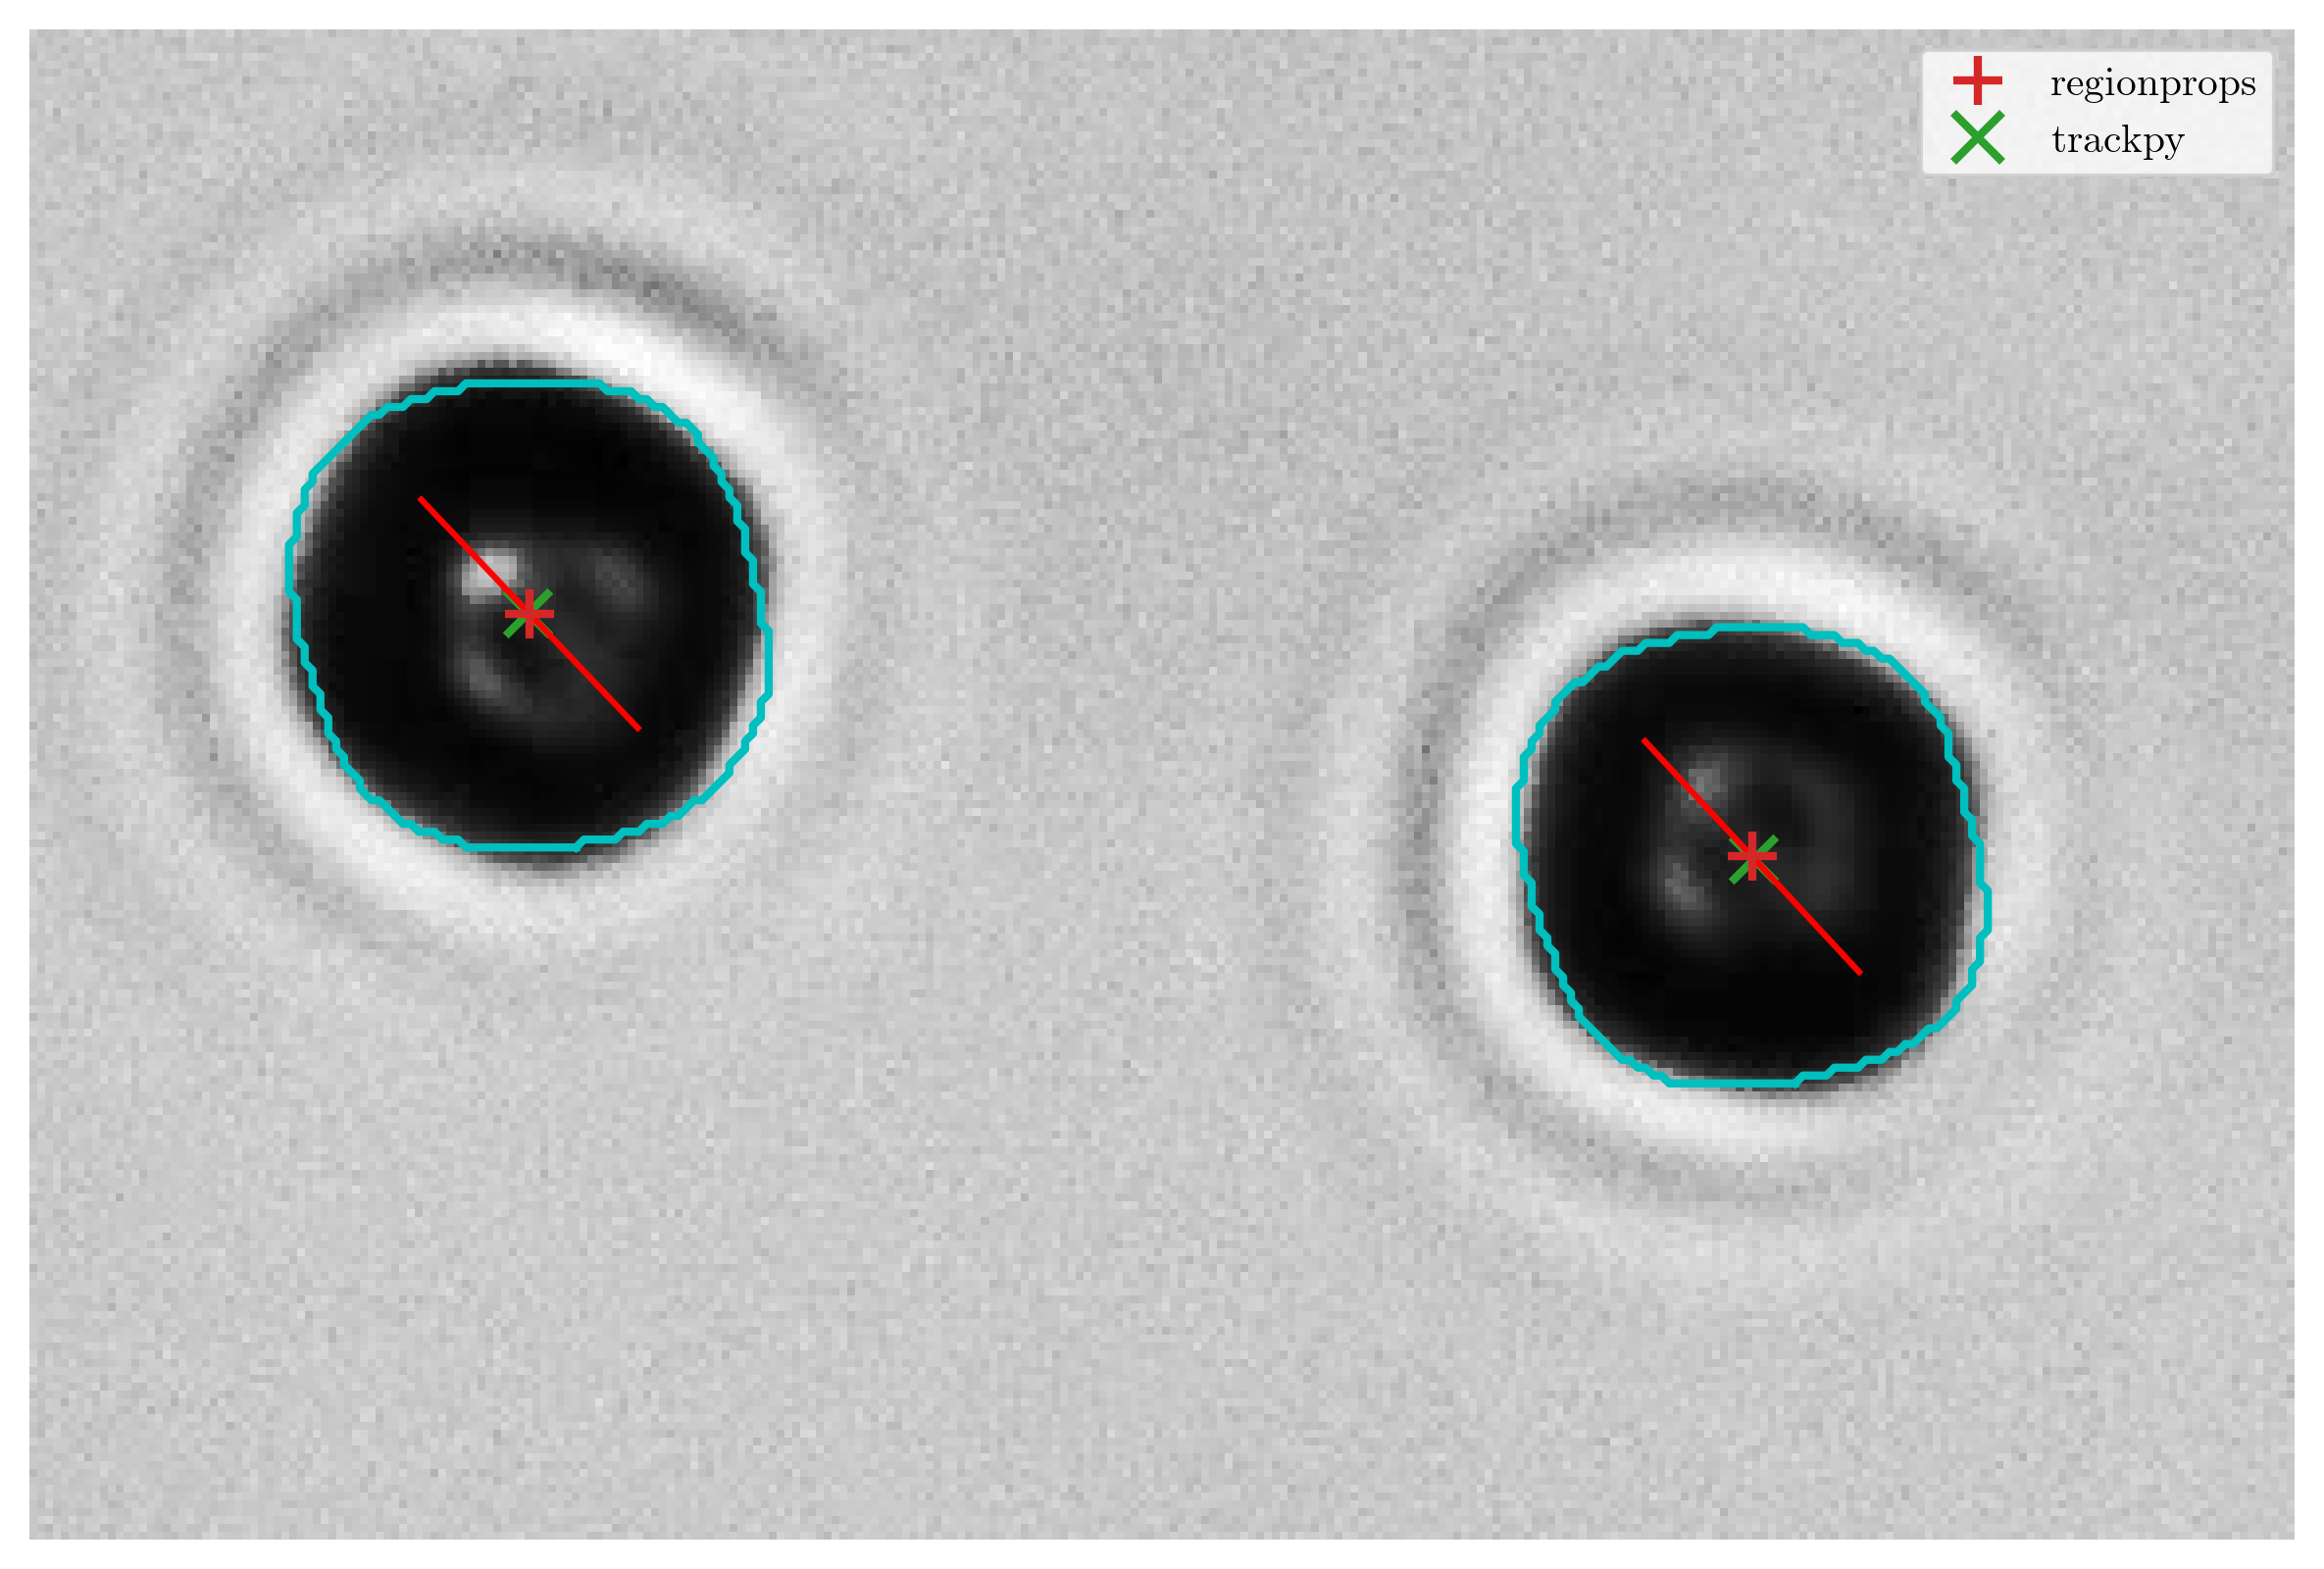

In [90]:
# Plot and compare scikit vs. trackpy for the positions of the particles

ARROW_LEN = 20   # half-length of orientation line in pixels

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(im2, cmap="gray")

# regionprops: centroid + orientation line
for _, row in df.iterrows():
    cx, cy = row["x"], row["y"]
    theta_rad = np.radians(row["theta"])
    ev = np.array([np.cos(theta_rad), np.sin(theta_rad)])
    ax.plot(
        [cx - ARROW_LEN * ev[0], cx + ARROW_LEN * ev[0]],
        [cy - ARROW_LEN * ev[1], cy + ARROW_LEN * ev[1]],
        "r-", linewidth=1.5, 
    )
    ax.plot(cx, cy, "+", mec='tab:red', markersize=12, markeredgewidth=2)

for p in props:
    # Contour of this particle
    particle_mask = labeled == p.label
    contours = find_contours(particle_mask, level=0.5)
    for cnt in contours:
        ax.plot(cnt[:, 1], cnt[:, 0], 'c-', linewidth=2)  # note: cnt is (row, col) → swap for plot

# trackpy: centroid only
ax.scatter(f2["x"], f2["y"], s=120, marker="x",
           color="tab:green", linewidths=2, label="trackpy")

ax.legend(handles=[
    plt.Line2D([0], [0], marker="+", mec="tab:red", linestyle="None", markersize=12, markeredgewidth=2, label="regionprops"),
    plt.Line2D([0], [0], marker="x", mec="tab:green", linestyle="None", markersize=12, markeredgewidth=2, label="trackpy"),
], loc="upper right")
ax.axis("off")
plt.tight_layout()
plt.show()

In [91]:
# fig.savefig()

# Several Images: Tracking and Linking

## Input

In [141]:
start = 0
stop = len(frames)
step = 1

In [142]:
# n_workers = 4

In [143]:
path2vid

'/home/nfares/postdoc/experiments/sam/shell_stuck_on_surface/TriAmineChip3/position2_NaOH_2_going_back_from_salt/1Hz_3.5_3.2_c.mp4'

In [144]:
# path2folder = './'

# vidname = path2vid[len(path2folder):path2vid.find('.mp4')]
# savename = path2folder + 'trajectories_' + vidname

savename = '/home/nfares/postdoc/experiments/tracking/tracking_datasam/TriAmineChip3_position2_NaOH_2_going_back_from_salt_1Hz_3p5_3p2_c'

print(savename)

/home/nfares/postdoc/experiments/tracking/tracking_datasam/TriAmineChip3_position2_NaOH_2_going_back_from_salt_1Hz_3p5_3p2_c


## Perform Tracking

In [145]:
def track_frame(i: int, frames, bg: np.ndarray, blur_sigma: float, thresh_method: str, thresh_value: int, min_area: int, max_area: int, verbose=False):
    im1 = frames[i]
    im2 = remove_background(im1, bg)
    binary = make_binary(im2, blur_sigma=blur_sigma, thresh_method=thresh_method, thresh_value=thresh_value)
    props, labeled = scikit_tracking(binary, min_area=min_area, max_area=max_area, verbose=verbose)
    df = _props2df(props)
    df['frame'] = i
    # dfs.append(df)
    # counts[i] = len(df)
    return df, props, labeled

In [146]:
args_track = (frames, bg, BLUR_SIGMA, THRESH_METHOD, THRESH_VALUE, MIN_AREA, MAX_AREA)

In [147]:
# Serial method 

dfs = []
counts = np.zeros((stop-start) // step)
save_indices = []
save_props = []
save_labeled = []

t0 = time.time()

for i in tqdm(range(start, stop, step)):
    df, props, labeled = track_frame(i, *args_track)
    dfs.append(df)
    counts[i] = len(df)
    if i % 100 == 0:
        save_indices.append(i)
        save_props.append(props)
        save_labeled.append(labeled)

f = pd.concat(dfs, ignore_index=True)

t1 = time.time()
deltatime = t1 - t0
print()
print("Wall time: {0} min {1} s".format(deltatime // 60, deltatime % 60))

del df, dfs

100%|██████████| 45394/45394 [12:42<00:00, 59.51it/s]



Wall time: 12.0 min 43.69651007652283 s


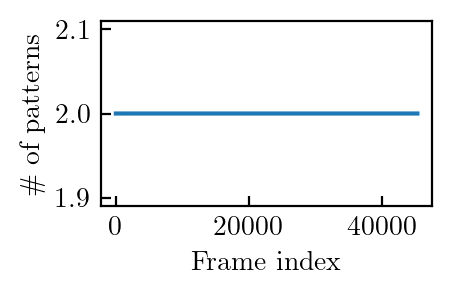

In [148]:
fig, ax = plt.subplots(1, 1, figsize=(6/2.54, 4/2.54))
ax.plot(np.arange(start, stop, step), counts, '-')
ax.set(xlabel='Frame index', ylabel=r'\# of patterns')
plt.tight_layout()
plt.show()

In [149]:
f.head()

,x,y,theta,area,minor_axis,major_axis,ecc,frame
0,62.772294,73.648741,8.714272,2938.0,60.187648,63.523365,0.319790,0
1,218.237464,104.878940,27.879526,2792.0,58.266383,61.215489,0.306644,0
2,62.780803,73.648060,9.253133,2938.0,60.185952,63.528090,0.320078,1
3,218.237464,104.878940,27.879526,2792.0,58.266383,61.215489,0.306644,1
4,62.780803,73.648060,9.253133,2938.0,60.185952,63.528090,0.320078,2


In [150]:
# results = wt.process_video(video_path=path2vid, start=start, stop=stop, step=step, 
#                            bg=bg, blur_sigma=BLUR_SIGMA, thresh_method=THRESH_METHOD, thresh_value=THRESH_VALUE, min_area=MIN_AREA, max_area=MAX_AREA, invert=True, 
#                            n_workers=n_workers, 
#                            )

In [151]:
# Check about duplicates
f[f.duplicated(subset=['frame', 'x', 'y'])]

,x,y,theta,area,minor_axis,major_axis,ecc,frame


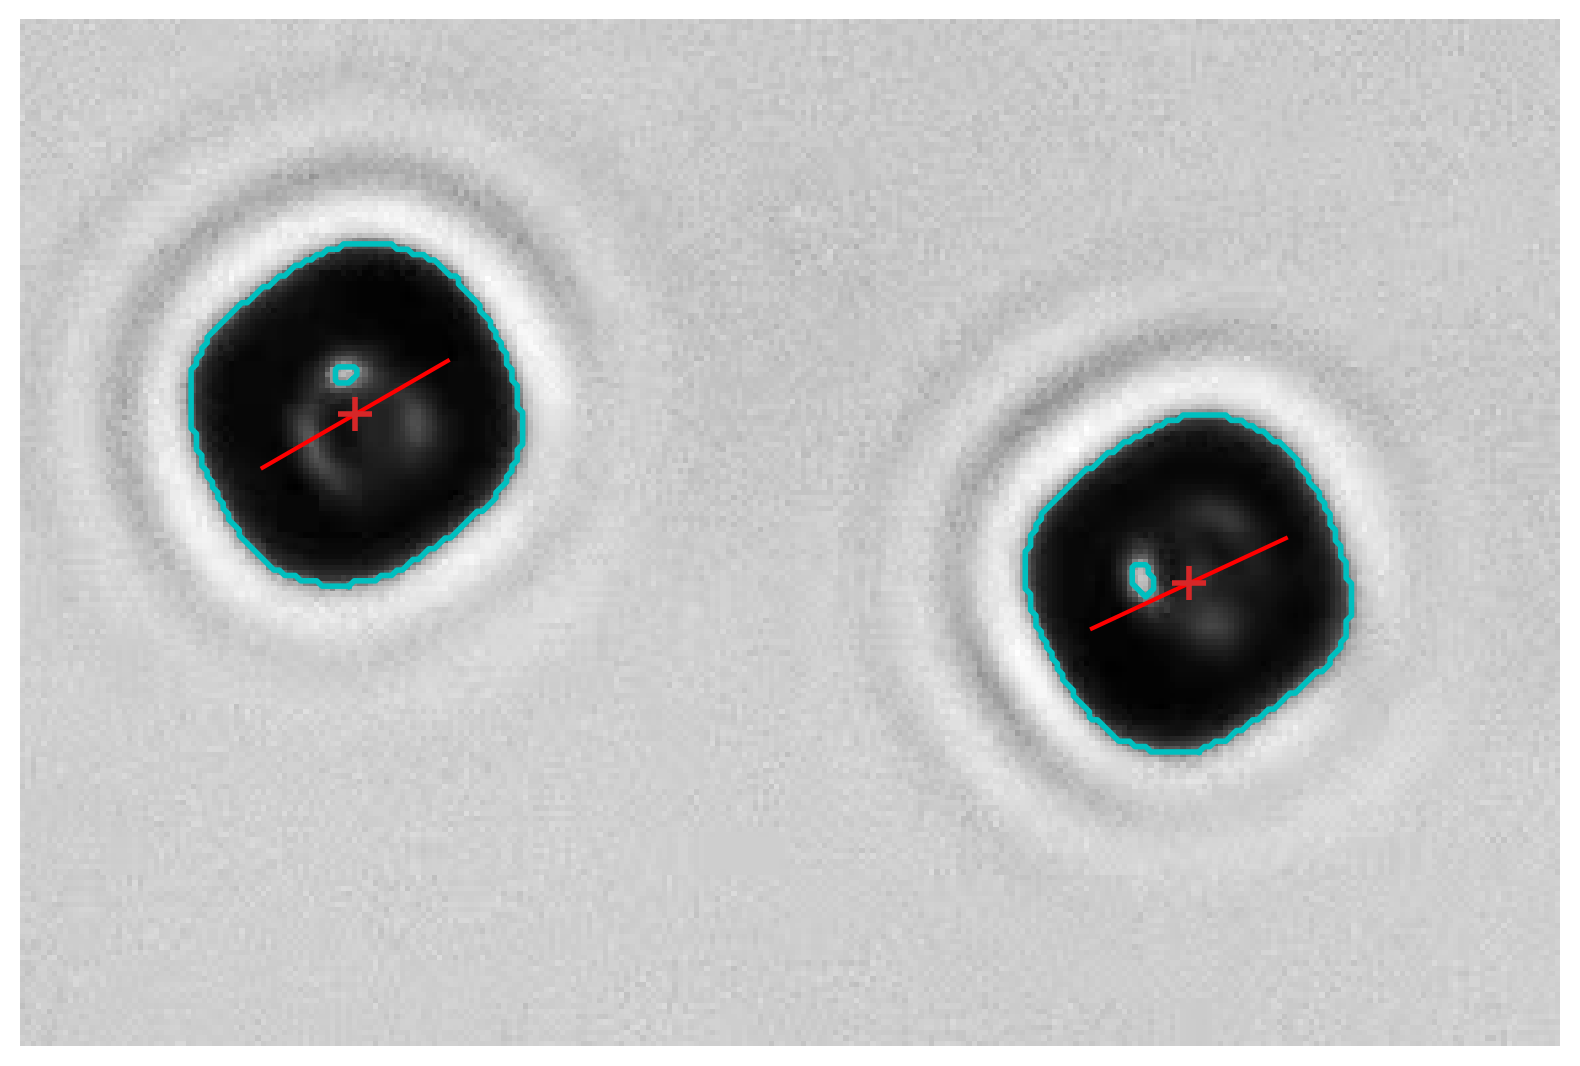

In [154]:
# Check on one image

i = 100

im2 = remove_background(frames[i], bg)
props = save_props[i//100]
labeled = save_labeled[i//100]

df = f[f['frame'] == i]

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(im2, cmap="gray")

# regionprops: centroid + orientation line
for _, row in df.iterrows():
    cx, cy = row["x"], row["y"]
    theta_rad = np.radians(row["theta"])
    ev = np.array([np.cos(theta_rad), np.sin(theta_rad)])
    ax.plot(
        [cx - ARROW_LEN * ev[0], cx + ARROW_LEN * ev[0]],
        [cy - ARROW_LEN * ev[1], cy + ARROW_LEN * ev[1]],
        "r-", linewidth=1.5, 
    )
    ax.plot(cx, cy, "+", mec='tab:red', markersize=12, markeredgewidth=2)

for p in props:
    # Contour of this particle
    particle_mask = labeled == p.label
    contours = find_contours(particle_mask, level=0.5)
    for cnt in contours:
        ax.plot(cnt[:, 1], cnt[:, 0], 'c-', linewidth=2)  # note: cnt is (row, col) → swap for plot

# ax.legend(handles=[
#     plt.Line2D([0], [0], marker="+", mec="tab:red", linestyle="None", markersize=12, markeredgewidth=2, label="regionprops"),
# ], loc="upper right")
ax.axis("off")
plt.tight_layout()
plt.show()

## Perform linking

In [155]:
# Inputs

search_range = 10
memory = 25

stubs_threshold = 100

In [156]:
# Link trajectories

# tp.quiet()
tracks = tp.link(f, search_range=search_range, memory=memory)

Frame 45393: 2 trajectories present.


In [157]:
tracks.head()

,x,y,theta,area,minor_axis,major_axis,ecc,frame,particle
0,62.772294,73.648741,8.714272,2938.0,60.187648,63.523365,0.319790,0,0
1,218.237464,104.878940,27.879526,2792.0,58.266383,61.215489,0.306644,0,1
2,62.780803,73.648060,9.253133,2938.0,60.185952,63.528090,0.320078,1,0
3,218.237464,104.878940,27.879526,2792.0,58.266383,61.215489,0.306644,1,1
4,62.780803,73.648060,9.253133,2938.0,60.185952,63.528090,0.320078,2,0


In [158]:
# Filter too-short trajectories

tracks1 = tp.filter_stubs(tracks, threshold=stubs_threshold)
# t1.index.name = None
tracks1 = tracks1.set_index(np.arange(len(tracks1)), drop=True)

In [160]:
tracks1.head()

,x,y,theta,area,minor_axis,major_axis,ecc,frame,particle
0,62.772294,73.648741,8.714272,2938.0,60.187648,63.523365,0.319790,0,0
1,218.237464,104.878940,27.879526,2792.0,58.266383,61.215489,0.306644,0,1
2,62.780803,73.648060,9.253133,2938.0,60.185952,63.528090,0.320078,1,0
3,218.237464,104.878940,27.879526,2792.0,58.266383,61.215489,0.306644,1,1
4,62.780803,73.648060,9.253133,2938.0,60.185952,63.528090,0.320078,2,0


In [161]:
# Compare the number of particles in the unfiltered and filtered data.
print('Before:', tracks['particle'].nunique())
print('After:', tracks1['particle'].nunique())

Before: 2
After: 2


In [162]:
# Filter with conditions on tracked particles
tracks2 = tracks1[((tracks1['ecc'] < 0.9))]

In [163]:
tracks2.head()

,x,y,theta,area,minor_axis,major_axis,ecc,frame,particle
0,62.772294,73.648741,8.714272,2938.0,60.187648,63.523365,0.319790,0,0
1,218.237464,104.878940,27.879526,2792.0,58.266383,61.215489,0.306644,0,1
2,62.780803,73.648060,9.253133,2938.0,60.185952,63.528090,0.320078,1,0
3,218.237464,104.878940,27.879526,2792.0,58.266383,61.215489,0.306644,1,1
4,62.780803,73.648060,9.253133,2938.0,60.185952,63.528090,0.320078,2,0


In [164]:
print("# of tracked particles = {}".format(tracks2['particle'].nunique()))

# of tracked particles = 2


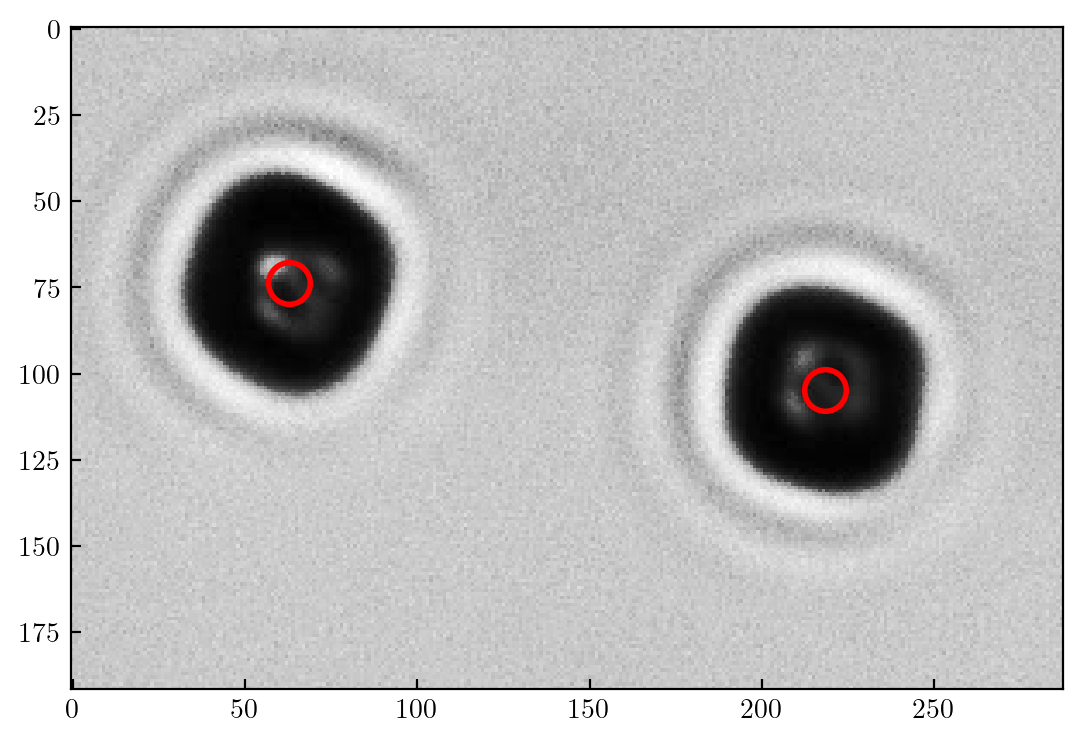

In [165]:
i = 1
tp.annotate(tracks2[tracks2['frame'] == start+i], frames[start+i]);

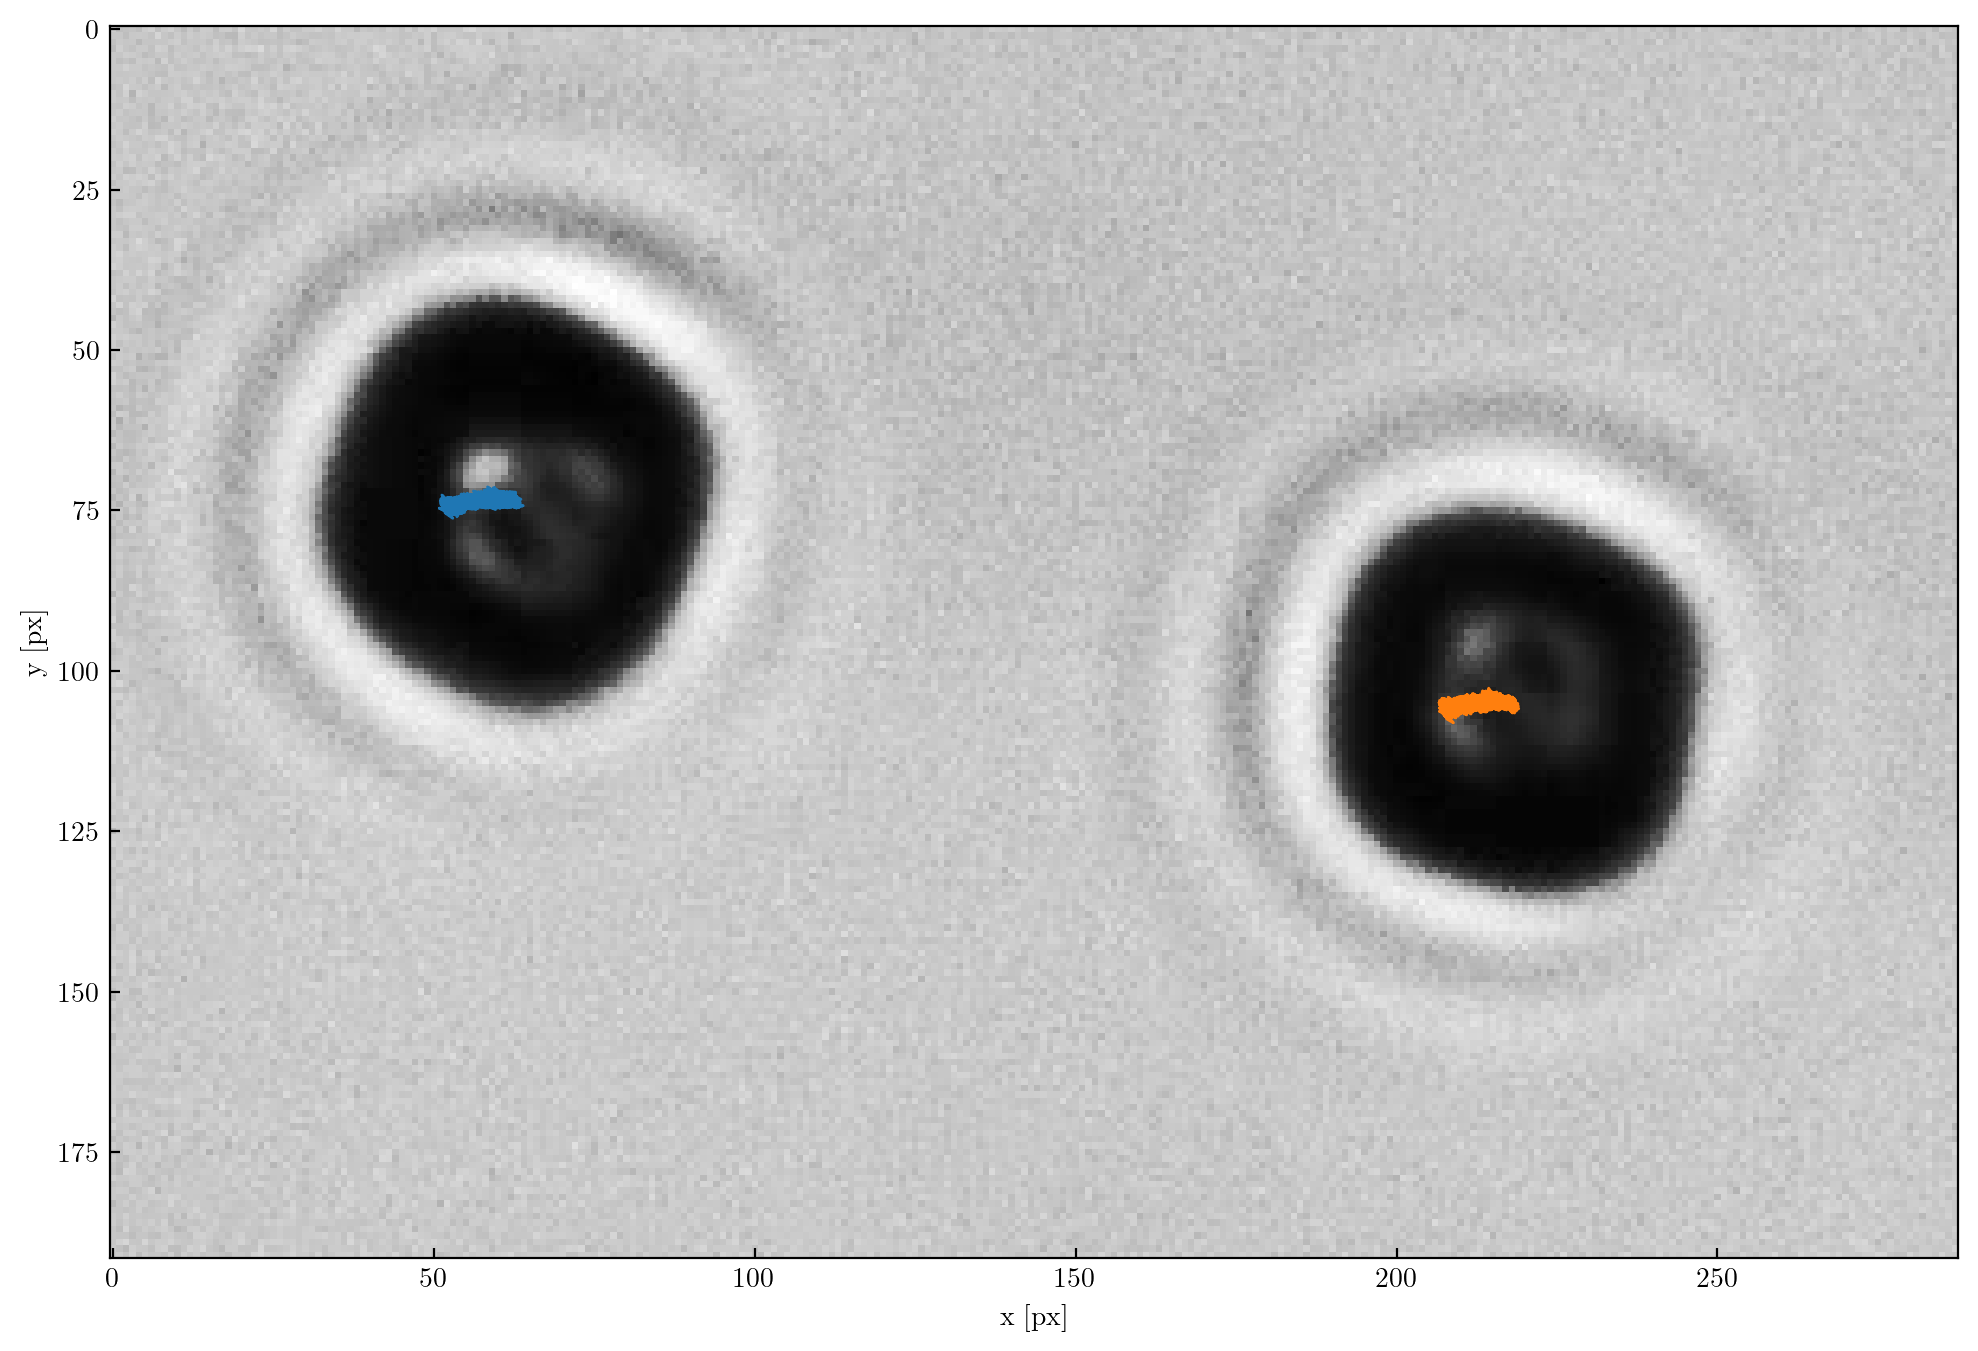

In [166]:
plt.figure(figsize=(15, 8))
plt.imshow(frames[start])
tp.plot_traj(tracks2);

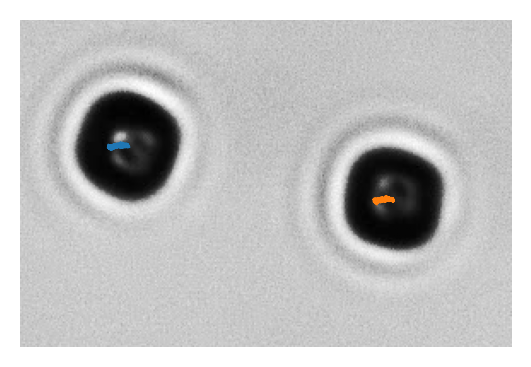

In [167]:
p = tracks2['particle'].unique()
N = tracks2['particle'].nunique()

fig, ax = plt.subplots(figsize=(7/2.54, 7/2.54))
ax.imshow(frames[start])
for i in range(len(p)):
    x = tracks2[tracks2['particle'] == p[i]]['x']
    y = tracks2[tracks2['particle'] == p[i]]['y']
    ax.plot(x, y, linewidth=0.5)
    # plt.annotate(str(p[i]), (x.iloc[0], y.iloc[0]), c='white', size=15)
ax.axis('off')
plt.tight_layout()
plt.show()
# fig.savefig('example_tracking.pdf', dpi=600, bbox_inches='tight')

In [168]:
# Check the displacement between consecutive frames for a given particle
p_id = 0
traj = tracks2[tracks2['particle'] == p_id].sort_values('frame')
traj['dx'] = traj['x'].diff()
traj['dy'] = traj['y'].diff()
traj['displacement'] = (traj['dx']**2 + traj['dy']**2)**0.5
print(traj['displacement'].max() / (px*1e6))

14.419483517513841


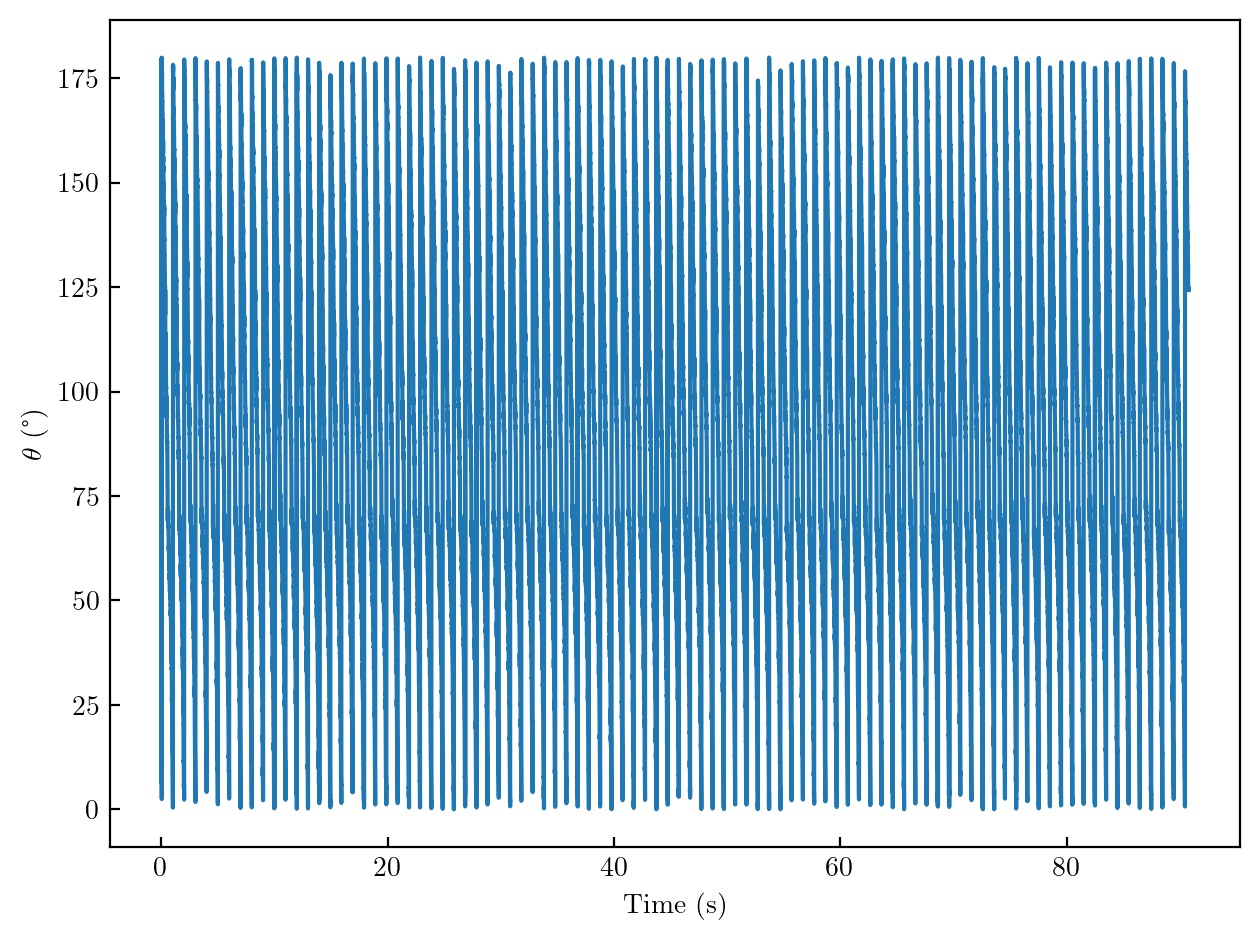

In [169]:
p_id = 0

traj = tracks2[tracks2['particle'] == p_id].sort_values('frame')

theta = traj['theta'].to_numpy()
time = traj['frame'].to_numpy() / fps 

fig, ax = plt.subplots(1, 1)
ax.plot(time, theta)
ax.set(xlabel='Time (s)', ylabel=r'$\theta$ (°)')
plt.tight_layout()
plt.show()


In [170]:
np.nanstd(theta)

np.float64(48.28756984553322)

In [171]:
np.nanstd(theta) / 360 * 100

np.float64(13.413213845981451)

In [172]:
def _unwrap_theta(theta):
    res = np.copy(theta)
    res = np.radians(res)
    res[~np.isnan(res)] = np.unwrap(res[~np.isnan(res)], period=np.pi)
    res = np.degrees(res)
    res = res % 360 
    return res 

def unwrap_theta(tracks: pd.DataFrame) -> pd.DataFrame:
    res = tracks.copy()
    res['theta_unwrapped'] = (
        tracks.groupby('particle')['theta']
        .transform(_unwrap_theta)
    )
    return res

In [173]:
tracks3 = unwrap_theta(tracks2)

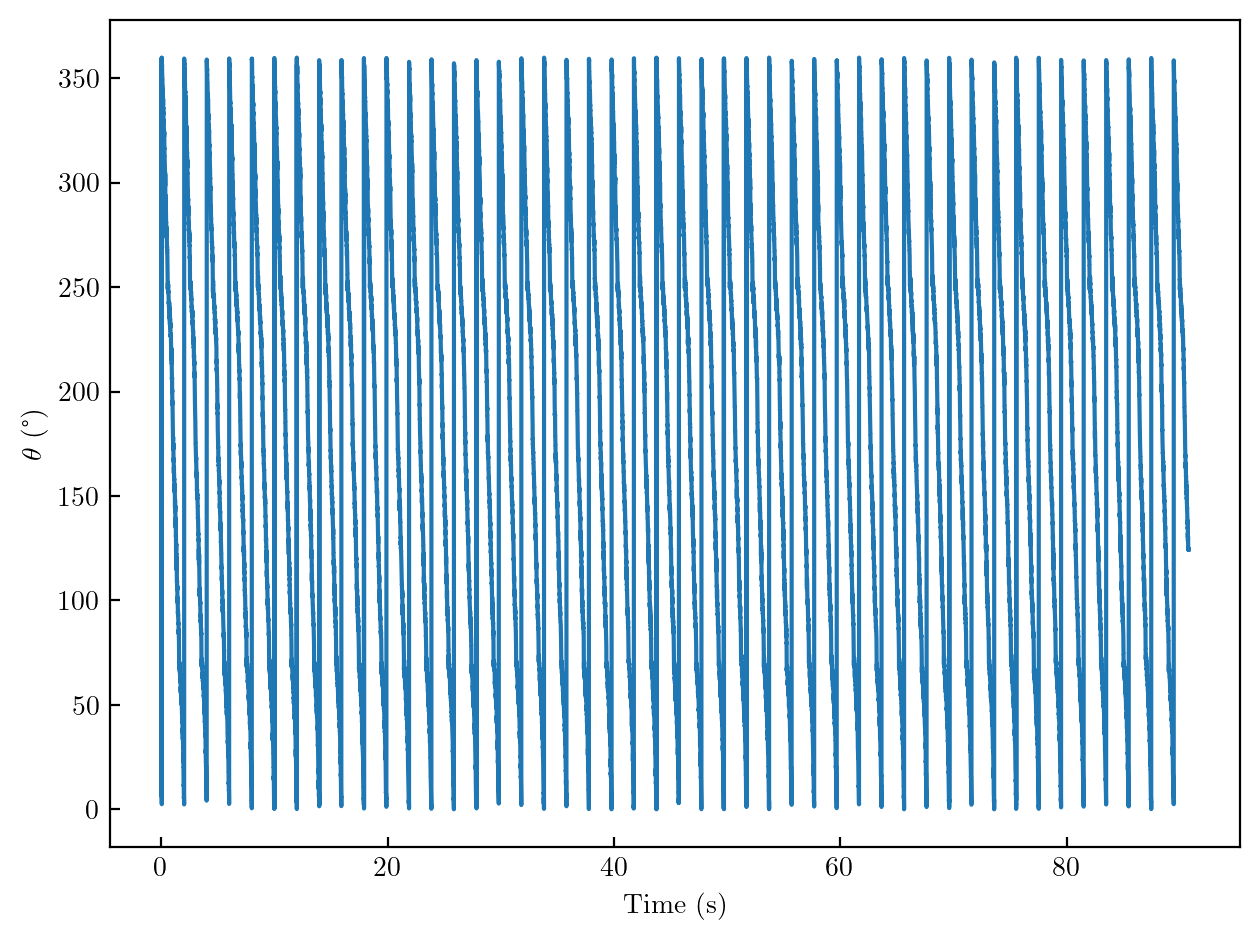

In [174]:
traj = tracks3[tracks3['particle'] == p_id].sort_values('frame')

theta = traj['theta_unwrapped'].to_numpy()
time = traj['frame'].to_numpy() / fps 

fig, ax = plt.subplots(1, 1)
ax.plot(time, theta)
ax.set(xlabel='Time (s)', ylabel=r'$\theta$ (°)')
plt.tight_layout()
plt.show()

In [175]:
tracks3.head()

,x,y,theta,area,minor_axis,major_axis,ecc,frame,particle,theta_unwrapped
0,62.772294,73.648741,8.714272,2938.0,60.187648,63.523365,0.319790,0,0,8.714272
1,218.237464,104.878940,27.879526,2792.0,58.266383,61.215489,0.306644,0,1,27.879526
2,62.780803,73.648060,9.253133,2938.0,60.185952,63.528090,0.320078,1,0,9.253133
3,218.237464,104.878940,27.879526,2792.0,58.266383,61.215489,0.306644,1,1,27.879526
4,62.780803,73.648060,9.253133,2938.0,60.185952,63.528090,0.320078,2,0,9.253133


## Quick analysis check

In [179]:
im = tp.imsd(tracks3, px*1e6, fps)  # microns per pixel, frames per second
em = tp.emsd(tracks3, px*1e6, fps)  # microns per pixel, frames per second

/tmp/ipykernel_1300655/2053213781.py:7: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(f_diffusion, lag[lagmin:lagmax], em[lagmin:lagmax], p0=[1e-2, 0])


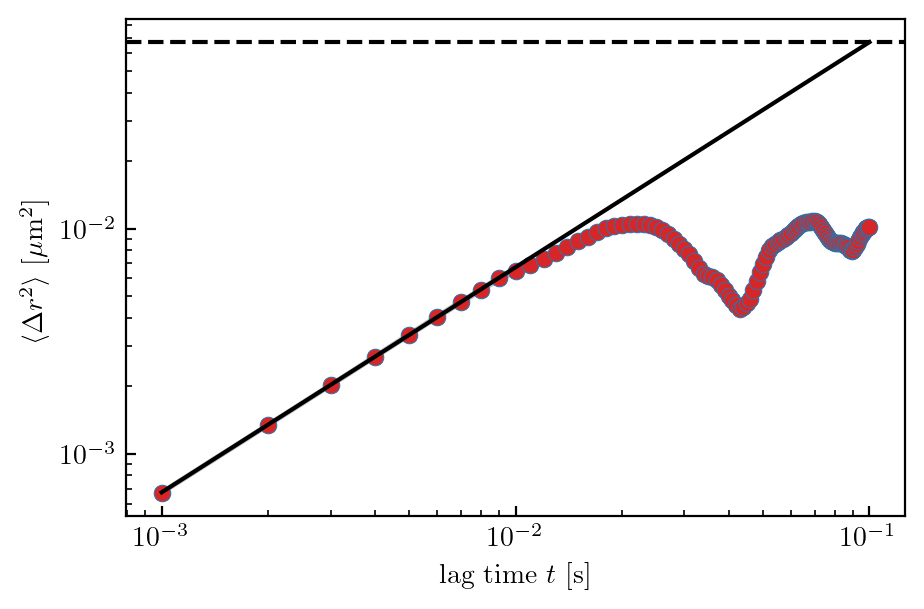

In [180]:
lag = em.index

f_diffusion = lambda t, D, d: 4*D*t+(2*d)**2

lagmin = 0
lagmax = 5
popt, _ = curve_fit(f_diffusion, lag[lagmin:lagmax], em[lagmin:lagmax], p0=[1e-2, 0])

fig, ax = plt.subplots(1, 1, figsize=(12/2.54,8/2.54))
ax.plot(im.index, im, 'k-', alpha=0.25)  # black lines, semitransparent
ax.plot(em.index, em, 'o', mfc='tab:red', mew=0.33, mec='tab:blue')  
ax.plot(em.index, f_diffusion(em.index, *popt), ls='-', c='k')
ax.set(ylabel=r'$\langle \Delta r^2 \rangle$ [$\mu$m$^2$]',
       xlabel='lag time $t$ [s]')
ax.axhline(y=(2*px*1e6)**2, ls='--', c='k')
ax.set_xscale('log')
ax.set_yscale('log')
# ax.set(xlim=[None, 4e-2], ylim=[None, 2e-1])
plt.tight_layout()
plt.show()
# fig.savefig('quick_MSD.pdf', transparent=True, dpi=600, bbox_inches='tight')

In [181]:
print(popt)

[ 1.68238721e-01 -1.90332209e-07]


## Save

In [184]:
if not(already_saved):
    tracks3['x'] = tracks3['x'] * px
    tracks3['y'] = tracks3['y'] * px
    tracks3.to_pickle(savename)
    already_saved = True
else:
    print('Data already saved and converted.')

Data already saved and converted.
